# Latest investing trends memo for Venture Capital  
## A small Python project to track clean energy and mobility trends for a VC fund

I wanted to build a Python project that feels close to something I could actually use at a VC fund. The purpose of this project is to source information from the web around latest trends in clean energy for a venture capital fund, automate that entire process and in the end give them information of the highest priority sectors which they could invest in and the most recent news relevant for them. A venture capital fund invests a lot of time in this and especially analysts too which I feel can be automated. 

The idea is simple. I use Python to pull around 80 recent articles from Google News RSS across clean mobility and energy sectors like electric vehicles, batteries, charging infrastructure, hydrogen, renewables, grid/storage, and software/autonomy. Then I convert the results into a pandas table, clean the data, classify each article by sector, and analyze where the news is clustering.

I also add a separate NHTSA Recall API section. This is not part of the news table. It is a second data source that shows how an investor could check product safety or recall risk in mobility. For example, if a vehicle or battery product has multiple recalls, that becomes a diligence question before getting excited about the market trend.

Finally, I use MCP tools so Claude can query my article table (after cleaning from article pulls) and write a short VC-style trend memo. The goal is not just to collect headlines, but to turn news flow into a simple investor view of what sectors look active, what themes look investable, and what risks need more diligence. Please note while the flow and the architecture of the project is mine based on what we learnt in class but most of the heavy lifting of writing the code I have done using the LLMs like chat GPT and Claude. 

## 1. Setup

First I import the main libraries I need for the project.

- `requests` is used to pull data from the internet, including Google News RSS and the NHTSA API.
- `pandas` is used to convert the data into tables and analyze it.
- `matplotlib.pyplot` is used to create simple charts from the pandas analysis.
- `re` is used for simple keyword matching inside article titles.
- `getpass` is used so I can enter my Claude API key without hardcoding it in the notebook.
- `datetime` is used to work with dates and recent article timing.
- `xml.etree.ElementTree` is used to read the Google News RSS feed, because RSS comes in XML format.

The basic flow is: get data from the internet, turn it into a table, clean it, analyze it, and then use the results to create a VC-style memo.

In [37]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import re
from getpass import getpass
from datetime import datetime

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 50)

## 2. Build the search universe

Here I decide what kind of news I want Python to look for.

 I have created sector buckets like EVs, batteries, charging, hydrogen, renewables, grid, software, and climate.

While this makes the pull broader, but it keeps it organized. Later, each article already comes with the sector bucket that found it.

In [20]:
news_sector_queries = {
    "Electric Vehicles": '"electric vehicle" OR "electric car" OR "EV market"',
    "Battery": '"EV battery" OR lithium OR battery OR batteries OR "energy storage"',
    "Charging Infrastructure": '"EV charging" OR charger OR "charging infrastructure"',
    "Hydrogen": 'hydrogen OR fuelcell OR electrolyzer OR "green hydrogen"',
    "Renewable Energy": 'renewable OR solar OR wind OR "clean energy"',
    "Grid / Storage": 'grid OR storage OR utility OR "energy storage"',
    "Mobility / Transport": 'mobility OR fleet OR transport OR automotive OR truck OR bus',
    "Software / Autonomy": 'software OR telematics OR autonomous OR "fleet software"'
}

print("Number of sector queries:", len(news_sector_queries))

for sector, query in news_sector_queries.items():
    print(sector, "→", query)

Number of sector queries: 8
Electric Vehicles → "electric vehicle" OR "electric car" OR "EV market"
Battery → "EV battery" OR lithium OR battery OR batteries OR "energy storage"
Charging Infrastructure → "EV charging" OR charger OR "charging infrastructure"
Hydrogen → hydrogen OR fuelcell OR electrolyzer OR "green hydrogen"
Renewable Energy → renewable OR solar OR wind OR "clean energy"
Grid / Storage → grid OR storage OR utility OR "energy storage"
Mobility / Transport → mobility OR fleet OR transport OR automotive OR truck OR bus
Software / Autonomy → software OR telematics OR autonomous OR "fleet software"


## 3. Pull articles from Google News RSS

Now I pull recent articles from Google News RSS.

The simple idea is: Python sends a request to Google News, gets back a structured RSS feed, and I convert that feed into a pandas table. Please note, I first tried doing this via API calls to a platform called GDELT but I was constantly hitting my API rate limits so I had to change and go ahead with Google News. I have brought the API concept later on additionally to showcase my understanding of it.

I use `when:21d` inside the query, so the search is focused on  the latest three weeks and investors get latest articles. I have roughly pulled around 80 articles. This could definitely be scaled to 1000-10000 but I do hit my rate limits. So I have kept it around 80 to show the proof of concept.

In [22]:
def fetch_google_news_by_sector(
    sector_queries,
    min_articles=5,
    max_articles=80,
    days_back=21,
    max_per_sector=15
):
    """
    Pull recent English news articles from Google News RSS.

    This version does not force the same number of articles per sector.
    It pulls up to max_per_sector articles from each sector, combines everything,
    sorts by date, and then keeps the latest max_articles overall.
    """

    base_url = "https://news.google.com/rss/search"
    all_articles = []

    for sector, query in sector_queries.items():

        full_query = f"({query}) when:{days_back}d"

        params = {
            "q": full_query,
            "hl": "en-US",
            "gl": "US",
            "ceid": "US:en"
        }

        response = requests.get(base_url, params=params, timeout=30)

        print(f"{sector} | Status code:", response.status_code)

        if response.status_code != 200:
            print(f"Skipping {sector} because the request failed.")
            continue

        root = ET.fromstring(response.content)

        for item in root.findall(".//item")[:max_per_sector]:
            title = item.findtext("title")
            link = item.findtext("link")
            pub_date = item.findtext("pubDate")

            source_tag = item.find("source")
            source = source_tag.text if source_tag is not None else None

            all_articles.append({
                "title": title,
                "url": link,
                "domain": source,
                "seendate": pub_date,
                "language": "English",
                "sourcecountry": "United States",
                "initial_sector_query": sector
            })

    if len(all_articles) == 0:
        raise ValueError("No articles returned. Try changing the sector queries.")

    df = pd.DataFrame(all_articles)

    df = df.drop_duplicates(subset="url")

    df["published_datetime"] = pd.to_datetime(
        df["seendate"],
        errors="coerce",
        utc=True
    )

    df = (
        df
        .sort_values(by="published_datetime", ascending=False)
        .head(max_articles)
        .reset_index(drop=True)
    )

    if len(df) < min_articles:
        raise ValueError(
            f"Only {len(df)} articles returned. Try broadening the query or increasing days_back."
        )

    return df

## 4. Create the raw article table

Now I run the article pull.

The output becomes my first table: `df_articles`.

Think of this as my raw news inbox. It has article title, URL, source, date, language, source country, and the sector query that pulled the article.

In [23]:
df_articles = fetch_google_news_by_sector(
    sector_queries=news_sector_queries,
    min_articles=50,
    max_articles=80,
    days_back=21,
    max_per_sector=15
)

df_articles.head(10)

Electric Vehicles | Status code: 200
Battery | Status code: 200
Charging Infrastructure | Status code: 200
Hydrogen | Status code: 200
Renewable Energy | Status code: 200
Grid / Storage | Status code: 200
Mobility / Transport | Status code: 200
Software / Autonomy | Status code: 200


,title,url,domain,seendate,language,sourcecountry,initial_sector_query,published_datetime
0,"EV Market Stabilizes in Q2, as New Entries Help Slow Sharp Sales Decline - Cox Automotive Inc.",https://news.google.com/rss/articles/CBMie0FVX3lxTE54NzJmbFpfYngyRUxZVFhfeXpNdUVkcW5yV2NrNV9yQ0o1UFg2WTZUWmh6TG9KTG0...,Cox Automotive Inc.,"Fri, 10 Jul 2026 15:04:26 GMT",English,United States,Electric Vehicles,2026-07-10 15:04:26+00:00
1,BMW falls below previous year’s battery-electric vehicle sales - electrive.com,https://news.google.com/rss/articles/CBMioAFBVV95cUxQc25SWWVYX2YyeGE3WmtmeHNGOTMwTmxpNDBNR1VBNXlSU0hUMGQwa2tmNlFpN2t...,electrive.com,"Fri, 10 Jul 2026 13:00:00 GMT",English,United States,Electric Vehicles,2026-07-10 13:00:00+00:00
2,Electric car drivers dodge Russia's hours-long fuel queues - Reuters,https://news.google.com/rss/articles/CBMirgFBVV95cUxQcXZLY3lyb0JibzdZVDN4cVBsVlVqWUlSV3BZakFEMFZJR3kwUXdCWTIxZHZSa0x...,Reuters,"Fri, 10 Jul 2026 08:03:44 GMT",English,United States,Electric Vehicles,2026-07-10 08:03:44+00:00
3,Could vehicle tested in Warwickshire be the electric car of the future? - BBC,https://news.google.com/rss/articles/CBMiWkFVX3lxTFBFajhNeThCaEpJblN4Qm9yVEwwXzNPSmUxTDRmZWpKVFd0bnYxS0VpeTVmbllaLVA...,BBC,"Fri, 10 Jul 2026 05:12:09 GMT",English,United States,Electric Vehicles,2026-07-10 05:12:09+00:00
4,Wilmington crashes injures multiple people after school bus driver runs red light: Police - 6abc Philadelphia,https://news.google.com/rss/articles/CBMitAFBVV95cUxNWEk0SkVnMy1nSVBET0pRTWxsZzdwbXVPQ3RYYVFLcHU3Y1NrX3JhS2xwU1RNV0l...,6abc Philadelphia,"Fri, 10 Jul 2026 02:22:52 GMT",English,United States,Mobility / Transport,2026-07-10 02:22:52+00:00
5,EPA proposes weakening heavy-duty truck pollution rules - NPR,https://news.google.com/rss/articles/CBMigAFBVV95cUxNN2tRYVFEamtGSTljMWNveFBtWFRDQ09xOTlubnhfdC1ZQmJIdVlKbFU4RnJLR2t...,NPR,"Thu, 09 Jul 2026 19:03:41 GMT",English,United States,Mobility / Transport,2026-07-09 19:03:41+00:00
6,"ChargePoint, Optimus Energy plan to expand EV charging network in Southeast US - WardsAuto",https://news.google.com/rss/articles/CBMiswFBVV95cUxOWmxtNHlPaDNNZVRWdUlDRGF3Q1dGajdPSExjSEZ4VVFaMUFlbzN2TVNMVnRnWW1...,WardsAuto,"Thu, 09 Jul 2026 16:45:23 GMT",English,United States,Charging Infrastructure,2026-07-09 16:45:23+00:00
7,Michigan revives EV charger expansion after federal funding reversal - thealpenanews.com,https://news.google.com/rss/articles/CBMisgFBVV95cUxPMDNiZlZrM19ZdHphYTUxSklfX1NMTDFnMklNeENnaHh5YVg4QXAxSzl2a3oyZkF...,thealpenanews.com,"Thu, 09 Jul 2026 15:58:33 GMT",English,United States,Charging Infrastructure,2026-07-09 15:58:33+00:00
8,"Global Battery Electric Vehicle Market Report Now Available; Profiles Tesla, BYD, and 33 Other Key Players - Yahoo F...",https://news.google.com/rss/articles/CBMimwFBVV95cUxOWjQ4UU9RVVlKakJaUFRiVFdIQW10Mmx2WVNWSndPa0l5LVF2MlEyeUVsYTJESkt...,Yahoo Finance,"Thu, 09 Jul 2026 15:50:00 GMT",English,United States,Electric Vehicles,2026-07-09 15:50:00+00:00
9,Electric Vehicle Market Continues to Evolve Despite Policy Shifts and Infrastructure Challenges - Morgan Lewis,https://news.google.com/rss/articles/CBMi0gFBVV95cUxPb2ptZVRUVk8zMG5KMm5vS2RCLTVoYXhhR1JFaTF5bjFFcFlicy1DcHpGS3AtUW5...,Morgan Lewis,"Thu, 09 Jul 2026 14:54:53 GMT",English,United States,Electric Vehicles,2026-07-09 14:54:53+00:00


## 5. Clean and inspect

Before doing any analysis, I check the table.

This is like opening a spreadsheet and making sure it is not broken.

I check:
- how many rows and columns I got
- whether any important fields are blank
- whether there are duplicate links
- which languages and countries show up
- which news domains appear

I am doing this because I do not want Claude or pandas to analyze bad data.

In [24]:
print("Shape of article table:", df_articles.shape)

display(df_articles.head())

print("\nMissing values:")
display(df_articles.isna().sum())

if "url" in df_articles.columns:
    duplicate_count = df_articles["url"].duplicated().sum()
    print("\nDuplicate URLs:", duplicate_count)

print("\nLanguage counts:")
display(df_articles["language"].value_counts())

print("\nSource country counts:")
display(df_articles["sourcecountry"].value_counts())

print("\nTop source domains:")
display(df_articles["domain"].value_counts().head(10))

Shape of article table: (80, 8)


,title,url,domain,seendate,language,sourcecountry,initial_sector_query,published_datetime
0,"EV Market Stabilizes in Q2, as New Entries Help Slow Sharp Sales Decline - Cox Automotive Inc.",https://news.google.com/rss/articles/CBMie0FVX3lxTE54NzJmbFpfYngyRUxZVFhfeXpNdUVkcW5yV2NrNV9yQ0o1UFg2WTZUWmh6TG9KTG0...,Cox Automotive Inc.,"Fri, 10 Jul 2026 15:04:26 GMT",English,United States,Electric Vehicles,2026-07-10 15:04:26+00:00
1,BMW falls below previous year’s battery-electric vehicle sales - electrive.com,https://news.google.com/rss/articles/CBMioAFBVV95cUxQc25SWWVYX2YyeGE3WmtmeHNGOTMwTmxpNDBNR1VBNXlSU0hUMGQwa2tmNlFpN2t...,electrive.com,"Fri, 10 Jul 2026 13:00:00 GMT",English,United States,Electric Vehicles,2026-07-10 13:00:00+00:00
2,Electric car drivers dodge Russia's hours-long fuel queues - Reuters,https://news.google.com/rss/articles/CBMirgFBVV95cUxQcXZLY3lyb0JibzdZVDN4cVBsVlVqWUlSV3BZakFEMFZJR3kwUXdCWTIxZHZSa0x...,Reuters,"Fri, 10 Jul 2026 08:03:44 GMT",English,United States,Electric Vehicles,2026-07-10 08:03:44+00:00
3,Could vehicle tested in Warwickshire be the electric car of the future? - BBC,https://news.google.com/rss/articles/CBMiWkFVX3lxTFBFajhNeThCaEpJblN4Qm9yVEwwXzNPSmUxTDRmZWpKVFd0bnYxS0VpeTVmbllaLVA...,BBC,"Fri, 10 Jul 2026 05:12:09 GMT",English,United States,Electric Vehicles,2026-07-10 05:12:09+00:00
4,Wilmington crashes injures multiple people after school bus driver runs red light: Police - 6abc Philadelphia,https://news.google.com/rss/articles/CBMitAFBVV95cUxNWEk0SkVnMy1nSVBET0pRTWxsZzdwbXVPQ3RYYVFLcHU3Y1NrX3JhS2xwU1RNV0l...,6abc Philadelphia,"Fri, 10 Jul 2026 02:22:52 GMT",English,United States,Mobility / Transport,2026-07-10 02:22:52+00:00



Missing values:


title                   0
url                     0
domain                  0
seendate                0
language                0
sourcecountry           0
initial_sector_query    0
published_datetime      0
dtype: int64


Duplicate URLs: 0

Language counts:


language
English    80
Name: count, dtype: int64


Source country counts:


sourcecountry
United States    80
Name: count, dtype: int64


Top source domains:


domain
NPR               3
Utility Dive      3
WSJ               3
NYC.gov           2
Reuters           2
CNBC              2
MIT News          2
Yahoo Finance     2
Yale E360         2
Autonocion.com    1
Name: count, dtype: int64

## 6. Create topic patterns

Now I need to convert article titles into useful VC categories.

I am not looking for companies. I am looking for themes.

For example:
- if the title mentions lithium or batteries, I call it Battery
- if it mentions charging or grid, I call it Charging Infrastructure
- if it mentions hydrogen or fuel cells, I call it Hydrogen
- if it mentions software or autonomy, I call it Software / Autonomy

This is the step where raw news starts becoming useful investor signal.

In [25]:
topic_patterns = {
    "Battery": [
        "battery",
        "batteries",
        "lithium",
        "sodium",
        "solidstate",
        "cathode",
        "anode",
        "recycling",
        "gigafactory",
        "nickel",
        "cobalt"
    ],
    "Charging Infrastructure": [
        "charging",
        "charger",
        "infrastructure",
        "grid",
        "power",
        "utility"
    ],
    "Hydrogen": [
        "hydrogen",
        "fuelcell",
        "electrolyzer"
    ],
    "Renewable Energy": [
        "renewable",
        "solar",
        "wind",
        "clean",
        "green"
    ],
    "Mobility / Transport": [
        "mobility",
        "transport",
        "vehicle",
        "automotive",
        "fleet",
        "truck",
        "bus",
        "scooter",
        "motorcycle"
    ],
    "Software / Autonomy": [
        "software",
        "telematics",
        "autonomous"
    ],
    "Climate / Carbon": [
        "climate",
        "carbon",
        "emissions",
        "decarbonization"
    ],
    "Supply Chain / Materials": [
        "supplychain",
        "mining",
        "copper",
        "rareearth",
        "lithium",
        "nickel",
        "cobalt"
    ]
}

## 7. Classify articles and add VC priority scoring

Now I classify each article and create a simple VC-style priority score.

Since the articles were pulled using sector-wise searches, I use the original sector query as the article’s sector. For example, if an article came from the Battery search, I classify it as Battery. This keeps the classification simple and avoids over-engineering.

Then I create a priority score for each article. Every article starts with a base score of 1. After that, Python checks the article title for investor-relevant signals.

If the title mentions funding, investment, partnerships, expansion, deployment, infrastructure, policy, regulation, market growth, or demand, the score increases. Each signal adds points to the same score, so the final score is the sum of all the signals found in that headline.

For example, if an article mentions both “funding” and “charging infrastructure expansion,” it gets points for funding, infrastructure, and expansion. That article will rank higher than a generic market update.

I also subtract a point if the title contains risk words like recall, investigation, fire, lawsuit, delay, bankruptcy, or loss.

The logic is simple: articles with more strong VC signals get higher scores, and the highest-scoring articles are treated as the highest-priority articles for the trend memo.


In [91]:
def assign_vc_signal_and_score(row):
    """
    Create a VC signal and priority score based on the article title and sector.
    """

    title = str(row["title"]).lower()

    score = 1
    signals = []

    # Strong positive investment signals
    if any(word in title for word in ["funding", "raises", "raised", "investment", "invests", "financing"]):
        score += 3
        signals.append("Funding / investment")

    if any(word in title for word in ["partnership", "partners", "deal", "contract", "agreement"]):
        score += 2
        signals.append("Partnership / commercial traction")

    if any(word in title for word in ["expansion", "expand", "launch", "rollout", "deploy", "deployment", "opens"]):
        score += 2
        signals.append("Expansion / deployment")

    if any(word in title for word in ["infrastructure", "charging", "grid", "storage", "hydrogen"]):
        score += 2
        signals.append("Infrastructure buildout")

    if any(word in title for word in ["regulation", "policy", "subsidy", "tax credit", "mandate"]):
        score += 1
        signals.append("Policy / regulation")

    if any(word in title for word in ["adoption", "demand", "sales", "growth", "market"]):
        score += 1
        signals.append("Market adoption")

    # Small sector-level boost
    if row["sector"] in ["Battery", "Charging Infrastructure", "Hydrogen", "Software / Autonomy"]:
        score += 1
        signals.append("High-interest sector")

    # Risk signals reduce the score slightly
    if any(word in title for word in ["recall", "investigation", "fire", "lawsuit", "delay", "bankruptcy", "loss"]):
        score -= 1
        signals.append("Risk / diligence issue")

    if len(signals) == 0:
        signal = "General market news"
    else:
        signal = " | ".join(signals)

    return pd.Series({
        "vc_signal": signal,
        "priority_score": score
    })


df_articles[["vc_signal", "priority_score"]] = df_articles.apply(
    assign_vc_signal_and_score,
    axis=1
)

df_articles[[
    "title",
    "sector",
    "vc_signal",
    "priority_score"
]].sort_values(by="priority_score", ascending=False).head(15)

,title,sector,vc_signal,priority_score
7,Michigan revives EV charger expansion after federal funding reversal - thealpenanews.com,Charging Infrastructure,Funding / investment | Expansion / deployment | High-interest sector,7
45,Springfield expansion of EV charging stations nears completion - NPR Illinois,Charging Infrastructure,Expansion / deployment | Infrastructure buildout | High-interest sector,6
6,"ChargePoint, Optimus Energy plan to expand EV charging network in Southeast US - WardsAuto",Charging Infrastructure,Expansion / deployment | Infrastructure buildout | High-interest sector,6
59,"Daimler Truck, MB Energy and Kawasaki Heavy Industries signed agreement to develop liquefied hydrogen supply chain t...",Hydrogen,Partnership / commercial traction | Infrastructure buildout | High-interest sector,6
27,New Electric-Vehicle Charging Station Opens in Downtown Santa Barbara - The Santa Barbara Independent,Electric Vehicles,Expansion / deployment | Infrastructure buildout,5
9,Electric Vehicle Market Continues to Evolve Despite Policy Shifts and Infrastructure Challenges - Morgan Lewis,Electric Vehicles,Infrastructure buildout | Policy / regulation | Market adoption,5
53,"America just trucked a complete 100-megawatt hydrogen plant to West Texas on skids — stacks, power electronics, wate...",Hydrogen,Infrastructure buildout | High-interest sector,4
50,China Builds World's Largest Green Hydrogen Plant - Fuel Cells Works,Hydrogen,Infrastructure buildout | High-interest sector,4
34,Hydrogen: clean fuel of the future — if we can find a cheap and clean way to ship it - MIT News,Hydrogen,Infrastructure buildout | High-interest sector,4
64,PJM anticipates new peak demand record as heat wave tests power grid - Utility Dive,Grid / Storage,Infrastructure buildout | Market adoption,4


## 8. Add VC signal

Now I add an investor lens to the classified articles.

A sector label tells me what the article is about, but it does not tell me how important the article is from a VC perspective. So I create a few extra columns to convert the news table into a research queue.

- `vc_signal` explains what kind of investor signal the article represents, such as funding, expansion, infrastructure buildout, policy, market adoption, or risk.


The scoring logic is additive. Each article starts with a base score, and then Python adds points when it finds strong VC signals in the title. If the title also contains risk words like recall, lawsuit, delay, or bankruptcy, the score is reduced.

This is not meant to be a perfect investment model. It is a simple first version of how an analyst could turn raw news into a ranked list of articles worth reviewing.

In [104]:
def assign_vc_signal(sector):
    signal_map = {
        "Battery": "Technology / battery signal",
        "Charging Infrastructure": "Infrastructure signal",
        "Hydrogen": "Energy transition signal",
        "Renewable Energy": "Clean energy deployment signal",
        "Grid / Storage": "Grid / storage infrastructure signal",
        "Electric Vehicles": "EV adoption signal",
        "Mobility / Transport": "Mobility adoption signal",
        "Software / Autonomy": "Software / automation signal"
    }

    return signal_map.get(sector, "General market signal")


df_articles["vc_signal"] = df_articles["sector"].apply(assign_vc_signal)

df_articles[[
    "title",
    "sector",
    "vc_signal",
    "url"
]].head(10)

,title,sector,vc_signal,url
0,"EV Market Stabilizes in Q2, as New Entries Help Slow Sharp Sales Decline - Cox Automotive Inc.",Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMie0FVX3lxTE54NzJmbFpfYngyRUxZVFhfeXpNdUVkcW5yV2NrNV9yQ0o1UFg2WTZUWmh6TG9KTG0...
1,BMW falls below previous year’s battery-electric vehicle sales - electrive.com,Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMioAFBVV95cUxQc25SWWVYX2YyeGE3WmtmeHNGOTMwTmxpNDBNR1VBNXlSU0hUMGQwa2tmNlFpN2t...
2,Electric car drivers dodge Russia's hours-long fuel queues - Reuters,Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMirgFBVV95cUxQcXZLY3lyb0JibzdZVDN4cVBsVlVqWUlSV3BZakFEMFZJR3kwUXdCWTIxZHZSa0x...
3,Could vehicle tested in Warwickshire be the electric car of the future? - BBC,Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMiWkFVX3lxTFBFajhNeThCaEpJblN4Qm9yVEwwXzNPSmUxTDRmZWpKVFd0bnYxS0VpeTVmbllaLVA...
4,Wilmington crashes injures multiple people after school bus driver runs red light: Police - 6abc Philadelphia,Mobility / Transport,Mobility adoption signal,https://news.google.com/rss/articles/CBMitAFBVV95cUxNWEk0SkVnMy1nSVBET0pRTWxsZzdwbXVPQ3RYYVFLcHU3Y1NrX3JhS2xwU1RNV0l...
5,EPA proposes weakening heavy-duty truck pollution rules - NPR,Mobility / Transport,Mobility adoption signal,https://news.google.com/rss/articles/CBMigAFBVV95cUxNN2tRYVFEamtGSTljMWNveFBtWFRDQ09xOTlubnhfdC1ZQmJIdVlKbFU4RnJLR2t...
6,"ChargePoint, Optimus Energy plan to expand EV charging network in Southeast US - WardsAuto",Charging Infrastructure,Infrastructure signal,https://news.google.com/rss/articles/CBMiswFBVV95cUxOWmxtNHlPaDNNZVRWdUlDRGF3Q1dGajdPSExjSEZ4VVFaMUFlbzN2TVNMVnRnWW1...
7,Michigan revives EV charger expansion after federal funding reversal - thealpenanews.com,Charging Infrastructure,Infrastructure signal,https://news.google.com/rss/articles/CBMisgFBVV95cUxPMDNiZlZrM19ZdHphYTUxSklfX1NMTDFnMklNeENnaHh5YVg4QXAxSzl2a3oyZkF...
8,"Global Battery Electric Vehicle Market Report Now Available; Profiles Tesla, BYD, and 33 Other Key Players - Yahoo F...",Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMimwFBVV95cUxOWjQ4UU9RVVlKakJaUFRiVFdIQW10Mmx2WVNWSndPa0l5LVF2MlEyeUVsYTJESkt...
9,Electric Vehicle Market Continues to Evolve Despite Policy Shifts and Infrastructure Challenges - Morgan Lewis,Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMi0gFBVV95cUxPb2ptZVRUVk8zMG5KMm5vS2RCLTVoYXhhR1JFaTF5bjFFcFlicy1DcHpGS3AtUW5...


## 9. NHTSA Recall API: safety-risk lens

Here I demonstrate my understanding of API . The news table tells me what topics are showing up.

But in mobility, I also want to think about product risk. A company or sector can have good momentum, but if there are safety or recall issues, that becomes a diligence question.

So I add one separate API example using the NHTSA recalls API. I am keeping this separate from the article table because news headlines usually do not give exact make, model, and year.

The simple flow is: Python asks NHTSA for recall data → NHTSA returns JSON → I convert it into a pandas table → I create a small recall-risk summary.

In [102]:
def fetch_nhtsa_recalls(make, model, year):
    """
    Pull vehicle recall data from NHTSA.

    Flow:
    Python request -> NHTSA JSON response -> pandas DataFrame
    """

    url = "https://api.nhtsa.gov/recalls/recallsByVehicle"

    params = {
        "make": make,
        "model": model,
        "modelYear": year
    }

    response = requests.get(url, params=params, timeout=30)

    print("Status code:", response.status_code)
    print("Request URL:", response.url)

    if response.status_code != 200:
        raise RuntimeError("NHTSA API request failed.")

    data = response.json()
    results = data.get("results", [])

    df_recalls = pd.DataFrame(results)

    return df_recalls

### Pull one NHTSA recall example

This step tests the NHTSA API on one real vehicle example: the 2023 Tesla Model 3.

The purpose is not to analyze every vehicle. I am using one example to show that Python can call a proper API, get official recall data, and convert it into a table.

This gives the project a safety-risk angle. The news table shows what sectors are trending, while this recall table shows how a VC analyst could check product risk before getting excited about a mobility trend.

In [44]:
df_recalls = fetch_nhtsa_recalls(
    make="Tesla",
    model="Model 3",
    year=2023
)

df_recalls.head()

Status code: 200
Request URL: https://api.nhtsa.gov/recalls/recallsByVehicle?make=Tesla&model=Model+3&modelYear=2023


,Manufacturer,NHTSACampaignNumber,parkIt,parkOutSide,overTheAirUpdate,ReportReceivedDate,Component,Summary,Consequence,Remedy,Notes,ModelYear,Make,Model,NHTSAActionNumber
0,"Tesla, Inc.",22V844000,False,False,True,15/11/2022,EXTERIOR LIGHTING:TAIL LIGHTS,"Tesla, Inc. (Tesla) is recalling certain 2023 Model 3 and 2020-2023 Model Y vehicles. One or both taillights may in...","A taillight that fails to illuminate may reduce the visibility of the vehicle, increasing the risk of a crash.","Tesla has released an over-the-air (OTA) software update, free of charge. Owner notification letters were mailed Ja...",Owners may also contact the National Highway Traffic Safety Administration Vehicle Safety Hotline at 1-888-327-4236 ...,2023,TESLA,MODEL 3,NaN
1,"Tesla, Inc.",21V834000,False,False,False,25/10/2021,AIR BAGS:SIDE/WINDOW:CURTAIN,"Tesla, Inc. (Tesla) is recalling certain 2020-2021, 2023 Model 3 vehicles. The left and/or right side curtain air b...","A twisted side curtain air bag may improperly deploy, increasing the risk of injury or occupant ejection during a cr...","Tesla Service will inspect and realign the left and right side curtain air bag as necessary, free of charge. Owner ...",Owners may also contact the National Highway Traffic Safety Administration Vehicle Safety Hotline at 1-888-327-4236 ...,2023,TESLA,MODEL 3,NaN
2,"Tesla, Inc.",23V085000,False,False,True,15/02/2023,STEERING:AUTOMATED/ADAPTIVE STEERING,"Tesla, Inc. (Tesla) is recalling certain 2016-2023 Model S, Model X, 2017-2023 Model 3, and 2020-2023 Model Y vehicl...",FSD Beta software that allows a vehicle to exceed speed limits or travel through intersections in an unlawful or unp...,"Tesla will release an over-the-air (OTA) software update, free of charge. Owner notification letters were mailed Ap...",Owners may also contact the National Highway Traffic Safety Administration Vehicle Safety Hotline at 1-888-327-4236 ...,2023,TESLA,MODEL 3,EA22002
3,"Tesla, Inc.",23V434000,False,False,False,19/06/2023,ELECTRICAL SYSTEM:PROPULSION SYSTEM:TRACTION BATTERY,"Tesla, Inc. (Tesla) is recalling certain 2023 Model 3 and Model Y vehicles. The pyrotechnic battery disconnect may ...","A defective battery disconnect may not isolate the vehicle's high voltage battery after a crash or fault detection, ...","Tesla Service will replace the pyrotechnic battery disconnect, free of charge. Owner notification letters were mail...",Owners may also contact the National Highway Traffic Safety Administration Vehicle Safety Hotline at 1-888-327-4236 ...,2023,TESLA,MODEL 3,NaN
4,"Tesla, Inc.",23V838000,False,False,True,12/12/2023,ELECTRICAL SYSTEM:ADAS:AUTONOMOUS/SELF DRIVING:SOFTWARE,"Tesla, Inc. (Tesla) is recalling 2012-2023 Model S, 2016-2023 Model X, 2017-2023 Model 3, and 2020-2023 Model Y vehi...","In certain circumstances when Autosteer is engaged, and the driver does not maintain responsibility for vehicle oper...","Tesla will release an over-the-air (OTA) software update, free of charge. Owner notification letters were mailed Fe...",Owners may also contact the National Highway Traffic Safety Administration Vehicle Safety Hotline at 1-888-327-4236 ...,2023,TESLA,MODEL 3,EA22002


### Inspect the recall table

The recall table shows official safety recall records from the NHTSA API for the vehicle I checked.

This table is useful because it adds a product-risk lens to the project. The news articles tell me what sectors are trending, but the recall table helps me ask whether there are safety or reliability issues that a mobility investor should investigate.

I check the table to make sure the API returned useful data.

If there are recalls, I look at what part of the vehicle had the issue, what the problem was, why it matters, and how it was fixed.

In [30]:
print("Recall table shape:", df_recalls.shape)

if df_recalls.empty:
    print("No recalls found for this vehicle.")
else:
    display(df_recalls.head())
    print("\nRecall columns:")
    display(df_recalls.columns)

Recall table shape: (11, 15)


,Manufacturer,NHTSACampaignNumber,parkIt,parkOutSide,overTheAirUpdate,ReportReceivedDate,Component,Summary,Consequence,Remedy,Notes,ModelYear,Make,Model,NHTSAActionNumber
0,"Tesla, Inc.",22V844000,False,False,True,15/11/2022,EXTERIOR LIGHTING:TAIL LIGHTS,"Tesla, Inc. (Tesla) is recalling certain 2023 Model 3 and 2020-2023 Model Y vehicles. One or both taillights may in...","A taillight that fails to illuminate may reduce the visibility of the vehicle, increasing the risk of a crash.","Tesla has released an over-the-air (OTA) software update, free of charge. Owner notification letters were mailed Ja...",Owners may also contact the National Highway Traffic Safety Administration Vehicle Safety Hotline at 1-888-327-4236 ...,2023,TESLA,MODEL 3,NaN
1,"Tesla, Inc.",21V834000,False,False,False,25/10/2021,AIR BAGS:SIDE/WINDOW:CURTAIN,"Tesla, Inc. (Tesla) is recalling certain 2020-2021, 2023 Model 3 vehicles. The left and/or right side curtain air b...","A twisted side curtain air bag may improperly deploy, increasing the risk of injury or occupant ejection during a cr...","Tesla Service will inspect and realign the left and right side curtain air bag as necessary, free of charge. Owner ...",Owners may also contact the National Highway Traffic Safety Administration Vehicle Safety Hotline at 1-888-327-4236 ...,2023,TESLA,MODEL 3,NaN
2,"Tesla, Inc.",23V085000,False,False,True,15/02/2023,STEERING:AUTOMATED/ADAPTIVE STEERING,"Tesla, Inc. (Tesla) is recalling certain 2016-2023 Model S, Model X, 2017-2023 Model 3, and 2020-2023 Model Y vehicl...",FSD Beta software that allows a vehicle to exceed speed limits or travel through intersections in an unlawful or unp...,"Tesla will release an over-the-air (OTA) software update, free of charge. Owner notification letters were mailed Ap...",Owners may also contact the National Highway Traffic Safety Administration Vehicle Safety Hotline at 1-888-327-4236 ...,2023,TESLA,MODEL 3,EA22002
3,"Tesla, Inc.",23V434000,False,False,False,19/06/2023,ELECTRICAL SYSTEM:PROPULSION SYSTEM:TRACTION BATTERY,"Tesla, Inc. (Tesla) is recalling certain 2023 Model 3 and Model Y vehicles. The pyrotechnic battery disconnect may ...","A defective battery disconnect may not isolate the vehicle's high voltage battery after a crash or fault detection, ...","Tesla Service will replace the pyrotechnic battery disconnect, free of charge. Owner notification letters were mail...",Owners may also contact the National Highway Traffic Safety Administration Vehicle Safety Hotline at 1-888-327-4236 ...,2023,TESLA,MODEL 3,NaN
4,"Tesla, Inc.",23V838000,False,False,True,12/12/2023,ELECTRICAL SYSTEM:ADAS:AUTONOMOUS/SELF DRIVING:SOFTWARE,"Tesla, Inc. (Tesla) is recalling 2012-2023 Model S, 2016-2023 Model X, 2017-2023 Model 3, and 2020-2023 Model Y vehi...","In certain circumstances when Autosteer is engaged, and the driver does not maintain responsibility for vehicle oper...","Tesla will release an over-the-air (OTA) software update, free of charge. Owner notification letters were mailed Fe...",Owners may also contact the National Highway Traffic Safety Administration Vehicle Safety Hotline at 1-888-327-4236 ...,2023,TESLA,MODEL 3,EA22002



Recall columns:


Index(['Manufacturer', 'NHTSACampaignNumber', 'parkIt', 'parkOutSide',
       'overTheAirUpdate', 'ReportReceivedDate', 'Component', 'Summary',
       'Consequence', 'Remedy', 'Notes', 'ModelYear', 'Make', 'Model',
       'NHTSAActionNumber'],
      dtype='object')

### Convert recall data into a simple risk signal

Now I turn the recall table into a short risk summary.

Instead of just showing the raw recall data, I count how many recalls were found and label the risk as Low, Medium, or High.

This makes the NHTSA data easier to understand from a VC diligence perspective.

In [87]:
recall_count = len(df_recalls)

if recall_count == 0:
    recall_risk_level = "Low"
    recall_risk_signal = "No recall signal found for this vehicle."
elif recall_count <= 3:
    recall_risk_level = "Medium"
    recall_risk_signal = "Some recall history found. This would require diligence."
else:
    recall_risk_level = "High"
    recall_risk_signal = "Multiple recalls found. This is a stronger safety-risk diligence signal."

recall_risk_summary = {
    "vehicle_checked": "2023 Tesla Model 3",
    "recall_count": recall_count,
    "recall_risk_level": recall_risk_level,
    "recall_risk_signal": recall_risk_signal
}

recall_risk_summary

{'vehicle_checked': '2023 Tesla Model 3',
 'recall_count': 11,
 'recall_risk_level': 'High',
 'recall_risk_signal': 'Multiple recalls found. This is a stronger safety-risk diligence signal.'}

### Show the most useful recall fields

The full NHTSA table can have many columns and some of them might not be useful for the reader. For the project, I only show the fields that are easiest to understand: component, summary, consequence, and remedy. 

In [88]:
useful_recall_columns = [
    "Manufacturer",
    "NHTSACampaignNumber",
    "ReportReceivedDate",
    "Component",
    "Summary",
    "Consequence",
    "Remedy"
]

available_recall_columns = [
    col for col in useful_recall_columns
    if col in df_recalls.columns
]

if df_recalls.empty:
    print("No recall rows to display.")
else:
    df_recalls[available_recall_columns].head()

## 10. Analyze the trends

Now I use pandas to answer the questions I actually care about.

I am not trying to predict the future. I am just asking:

- Which sectors are showing up most in the current article pull?
- Which source countries are showing up?
- What kind of VC signals are appearing?
- How many high-priority articles did I get?

This is the part where the article list becomes a small trend dashboard.

In [105]:
sector_summary = (
    df_articles
    .groupby("sector")
    .agg(
        article_count=("title", "count")
    )
    .sort_values(by="article_count", ascending=False)
    .reset_index()
)

sector_summary

,sector,article_count
0,Charging Infrastructure,13
1,Electric Vehicles,12
2,Hydrogen,11
3,Mobility / Transport,11
4,Software / Autonomy,10
5,Grid / Storage,9
6,Battery,8
7,Renewable Energy,6


In [106]:
signal_summary = (
    df_articles["vc_signal"]
    .value_counts()
    .reset_index()
)

signal_summary.columns = ["vc_signal", "article_count"]

signal_summary

,vc_signal,article_count
0,Infrastructure signal,13
1,EV adoption signal,12
2,Mobility adoption signal,11
3,Energy transition signal,11
4,Software / automation signal,10
5,Grid / storage infrastructure signal,9
6,Technology / battery signal,8
7,Clean energy deployment signal,6


In [109]:
top_articles = df_articles[[
    "title",
    "sector",
    "vc_signal",
    "url"
]].head(15)

top_articles

,title,sector,vc_signal,url
0,"EV Market Stabilizes in Q2, as New Entries Help Slow Sharp Sales Decline - Cox Automotive Inc.",Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMie0FVX3lxTE54NzJmbFpfYngyRUxZVFhfeXpNdUVkcW5yV2NrNV9yQ0o1UFg2WTZUWmh6TG9KTG0...
1,BMW falls below previous year’s battery-electric vehicle sales - electrive.com,Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMioAFBVV95cUxQc25SWWVYX2YyeGE3WmtmeHNGOTMwTmxpNDBNR1VBNXlSU0hUMGQwa2tmNlFpN2t...
2,Electric car drivers dodge Russia's hours-long fuel queues - Reuters,Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMirgFBVV95cUxQcXZLY3lyb0JibzdZVDN4cVBsVlVqWUlSV3BZakFEMFZJR3kwUXdCWTIxZHZSa0x...
3,Could vehicle tested in Warwickshire be the electric car of the future? - BBC,Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMiWkFVX3lxTFBFajhNeThCaEpJblN4Qm9yVEwwXzNPSmUxTDRmZWpKVFd0bnYxS0VpeTVmbllaLVA...
4,Wilmington crashes injures multiple people after school bus driver runs red light: Police - 6abc Philadelphia,Mobility / Transport,Mobility adoption signal,https://news.google.com/rss/articles/CBMitAFBVV95cUxNWEk0SkVnMy1nSVBET0pRTWxsZzdwbXVPQ3RYYVFLcHU3Y1NrX3JhS2xwU1RNV0l...
5,EPA proposes weakening heavy-duty truck pollution rules - NPR,Mobility / Transport,Mobility adoption signal,https://news.google.com/rss/articles/CBMigAFBVV95cUxNN2tRYVFEamtGSTljMWNveFBtWFRDQ09xOTlubnhfdC1ZQmJIdVlKbFU4RnJLR2t...
6,"ChargePoint, Optimus Energy plan to expand EV charging network in Southeast US - WardsAuto",Charging Infrastructure,Infrastructure signal,https://news.google.com/rss/articles/CBMiswFBVV95cUxOWmxtNHlPaDNNZVRWdUlDRGF3Q1dGajdPSExjSEZ4VVFaMUFlbzN2TVNMVnRnWW1...
7,Michigan revives EV charger expansion after federal funding reversal - thealpenanews.com,Charging Infrastructure,Infrastructure signal,https://news.google.com/rss/articles/CBMisgFBVV95cUxPMDNiZlZrM19ZdHphYTUxSklfX1NMTDFnMklNeENnaHh5YVg4QXAxSzl2a3oyZkF...
8,"Global Battery Electric Vehicle Market Report Now Available; Profiles Tesla, BYD, and 33 Other Key Players - Yahoo F...",Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMimwFBVV95cUxOWjQ4UU9RVVlKakJaUFRiVFdIQW10Mmx2WVNWSndPa0l5LVF2MlEyeUVsYTJESkt...
9,Electric Vehicle Market Continues to Evolve Despite Policy Shifts and Infrastructure Challenges - Morgan Lewis,Electric Vehicles,EV adoption signal,https://news.google.com/rss/articles/CBMi0gFBVV95cUxPb2ptZVRUVk8zMG5KMm5vS2RCLTVoYXhhR1JFaTF5bjFFcFlicy1DcHpGS3AtUW5...


## 11. Make simple charts

Now I create simple charts.

The goal is not to make fancy visuals. The goal is to make the pattern easy to explain.

For example, if Battery and Charging Infrastructure show up more than other sectors, I should be able to see that quickly.

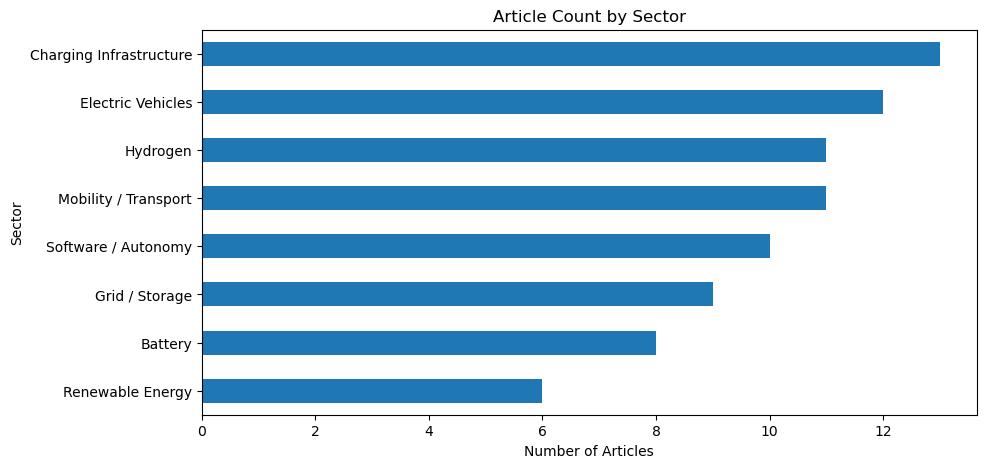

In [112]:
sector_counts = (
    df_articles["sector"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 5))
sector_counts.plot(kind="barh")

plt.title("Article Count by Sector")
plt.xlabel("Number of Articles")
plt.ylabel("Sector")
plt.show()

## 12. Save the final table

Now I save the final article table as a CSV.

This is important because the MCP server will read from this file.

So the flow is:
pandas table → CSV → MCP tools can query it.

In [115]:
df_articles.to_csv("ev_intel_topics.csv", index=False)

print("Saved final table to ev_intel_topics.csv")

Saved final table to ev_intel_topics.csv


## 13. Install MCP / Claude dependencies if needed

This cell makes the notebook easier to run on a new machine.

If these packages are already installed, this will be quick.

In [65]:
# Run this cell once if these packages are not already installed.
# The -q keeps the output shorter.

%pip install -q anthropic mcp nest_asyncio

Note: you may need to restart the kernel to use updated packages.


## 14. Claude API setup

Google News RSS and NHTSA do not need my Claude key.

But the final MCP-powered memo uses Claude, so I need my Anthropic API key.

I do not hardcode the key in the notebook. I enter it securely using `getpass`, so the key is not saved in the file.

In [71]:
ANTHROPIC_API_KEY = getpass("Enter your Anthropic API key: ")

Enter your Anthropic API key:  ········


## 15. Create MCP tools

Now I create the MCP server.

This is the part where my table becomes something Claude can use.

Instead of Claude guessing what is in the data, I give it tools:
- show sector trends
- show location trends
- show high-priority topics
- show articles for a specific sector

So Claude can ask my Python table questions before writing the final memo.

In [116]:
%%writefile ev_intel_server.py

from mcp.server.fastmcp import FastMCP
import pandas as pd

mcp = FastMCP("EV Intel Desk Lite")

DATA_PATH = "ev_intel_topics.csv"


def load_data():
    return pd.read_csv(DATA_PATH)


@mcp.tool()
def get_sector_trends() -> str:
    """
    Return article counts and average priority score by sector.
    """
    df = load_data()

    summary = (
        df.groupby("sector")
        .agg(
            article_count=("title", "count"),
            avg_priority_score=("priority_score", "mean")
        )
        .reset_index()
        .sort_values("article_count", ascending=False)
    )

    return summary.to_string(index=False)


@mcp.tool()
def get_location_trends() -> str:
    """
    Return article counts by source country.
    """
    df = load_data()

    summary = (
        df.groupby("sourcecountry")
        .agg(article_count=("title", "count"))
        .reset_index()
        .sort_values("article_count", ascending=False)
    )

    return summary.to_string(index=False)


@mcp.tool()
def get_high_priority_topics() -> str:
    """
    Return high-priority clean energy and mobility articles.
    """
    df = load_data()

    high_priority = df[df["is_high_priority"] == True]

    if high_priority.empty:
        return "No high-priority articles found in this pull."

    cols = ["title", "sector", "vc_signal", "priority_score", "url"]
    cols = [col for col in cols if col in high_priority.columns]

    return high_priority[cols].to_string(index=False)


@mcp.tool()
def get_articles_by_sector(sector: str) -> str:
    """
    Return articles for a specific sector, such as Battery, Hydrogen, or Charging Infrastructure.
    """
    df = load_data()

    filtered = df[df["sector"].str.lower() == sector.lower()]

    if filtered.empty:
        return f"No articles found for sector: {sector}"

    cols = ["title", "sector", "vc_signal", "sourcecountry", "url"]
    cols = [col for col in cols if col in filtered.columns]

    return filtered[cols].to_string(index=False)


if __name__ == "__main__":
    mcp.run()

Overwriting ev_intel_server.py


## 16. Create the MCP client

The server creates the tools.

Now I need a client that lets Claude talk to those tools.

The simple idea is:
I ask Claude a question → Claude decides which tool to call → Python runs the tool → Claude uses the result to answer.

In [117]:
%%writefile ev_mcp_client.py

import sys
from anthropic import Anthropic
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client


async def ask_server(server_file, user_question, anthropic_api_key):
    """
    Ask Claude a question and let Claude use MCP tools from the server.
    """

    client = Anthropic(api_key=anthropic_api_key)

    server_params = StdioServerParameters(
        command=sys.executable,
        args=[server_file]
    )

    async with stdio_client(server_params) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()

            tools_result = await session.list_tools()

            available_tools = [
                {
                    "name": tool.name,
                    "description": tool.description,
                    "input_schema": tool.inputSchema
                }
                for tool in tools_result.tools
            ]

            messages = [
                {
                    "role": "user",
                    "content": user_question
                }
            ]

            response = client.messages.create(
                model="claude-sonnet-4-5",
                max_tokens=1200,
                tools=available_tools,
                messages=messages
            )

            final_text_parts = []

            while True:
                tool_calls = [
                    block for block in response.content
                    if block.type == "tool_use"
                ]

                text_blocks = [
                    block.text for block in response.content
                    if block.type == "text"
                ]

                final_text_parts.extend(text_blocks)

                if not tool_calls:
                    break

                messages.append(
                    {
                        "role": "assistant",
                        "content": response.content
                    }
                )

                tool_results = []

                for tool_call in tool_calls:
                    result = await session.call_tool(
                        tool_call.name,
                        tool_call.input
                    )

                    tool_results.append(
                        {
                            "type": "tool_result",
                            "tool_use_id": tool_call.id,
                            "content": result.content[0].text
                        }
                    )

                messages.append(
                    {
                        "role": "user",
                        "content": tool_results
                    }
                )

                response = client.messages.create(
                    model="claude-sonnet-4-5",
                    max_tokens=1200,
                    tools=available_tools,
                    messages=messages
                )

            return "\n".join(final_text_parts)

Overwriting ev_mcp_client.py


## 17. MCP-powered VC takeaway

This is the final output.

I am not asking Claude to write a generic clean energy summary.

I am asking Claude to use my MCP tools, look at the actual article table, and write a memo based on what the data shows.

This is the "AI analyst" part of the project. I've created this based on how I would like the venture capital fund to read it and how I would want information to flow to them. 

In [82]:
import nest_asyncio
nest_asyncio.apply()

from ev_mcp_client import ask_server

In [86]:
import asyncio

final_question = """
Using the EV Intel Desk tools, write a VC trend memo.

The goal is not just to list which sectors have the most articles.
The goal is to explain what trends are actually showing up inside the data.

Do not focus on individual companies.
Use company examples only if they help explain a broader trend.
Avoid generic clean energy commentary.

Use this exact format:

1. Top sectors showing up
- Give exactly 3 bullet points.
- Each bullet should follow this structure:
  Sector name + article count → what is actually happening in that sector → why this matters for a VC.
- Do not just say the sector has high volume. Explain the story inside the sector.
- Example style: Charging Infrastructure → the data is not just showing more chargers, it is showing expansion, regulation, and institutional deployment. This matters because the opportunity may be in operating software, site selection, payments, and grid integration rather than only charger hardware.

Source: Google News RSS sector-level article pull.

2. Most investable themes
- Give exactly 3 bullet points.
- Each bullet should explain the theme in plain English.
- For each theme, include:
  what is changing → why now → what kind of startup could benefit.
- Focus on themes, not individual companies.

Source: EV Intel Desk pandas sector summary and priority-score analysis.

3. Main risks / diligence questions
- Give exactly 3 bullet points.
- Each bullet should explain the risk clearly, not just name it.
- Include one bullet that mentions the NHTSA recall-risk check.
- Explain how recall or safety data would affect VC diligence in mobility or battery startups.

Source: NHTSA Recall API and EV Intel Desk risk scoring.

4. Final takeaway
- Write exactly 4 lines.
- Line 1: what the data says overall.
- Line 2: where the investable opportunity seems to be moving.
- Line 3: what risk a VC should not ignore.
- Line 4: what I would track next if I kept running this project weekly.

Maximum length: 500 words.
"""

print("Starting MCP memo call...")

try:
    memo = await asyncio.wait_for(
        ask_server(
            "ev_intel_server.py",
            final_question,
            ANTHROPIC_API_KEY
        ),
        timeout=90
    )

    print("MCP memo call finished.")
    print(memo)

except asyncio.TimeoutError:
    print("The MCP call took more than 90 seconds and was stopped.")
    print("This usually means the server or Claude tool loop is hanging.")

Starting MCP memo call...
MCP memo call finished.
Let me get sector-specific data to understand trends within key categories:
---

## **VC Trend Memo: EV Intel Desk**

### **1. Top sectors showing up**

- **Charging Infrastructure (13 articles, avg priority 3.0)** → The data shows expansion, regulation, and institutional deployment rather than just volume. Stories include Michigan reviving charger expansion after federal reversal, Colorado adding regulatory oversight for fee-based stations, and ChargePoint adding 200+ ports in the Southeast. This matters because the investable opportunity is shifting to operating software, grid integration, site selection tools, and payments platforms—not just charger hardware manufacturing.

- **Hydrogen (11 articles, avg priority 3.0)** → The activity centers on industrial deployment, logistics infrastructure, and supply chain buildout. Highlights include a factory-built 100MW hydrogen plant shipped to Texas for e-fuels, Daimler/Kawasaki establishing

## Reflection

This project started with a simple question: can I use Python to create a lightweight research workflow for a VC fund and help automate the time they invest in looking for latest trends and investable sectors.


The project uses:
- Google News RSS to source recent articles from the last three weeks
- pandas to clean and analyze the news table
- keyword logic to classify sectors and VC signals
- NHTSA Recall API as a separate safety-risk lens
- charts to show patterns
- MCP tools so Claude can query my table
- Claude to write the final VC-style trend memo

There were some challenges that I hit during the project. One was hitting the API rate limits. Initially I was pulling news using API but I was quickly running into a dead end because of the rate limits. So I changed that to Google RSS News Feed which helped manage that and to demonstrate the concept of API, I used it separately for a smaller search task. This was to assess risks of vehicle recalls. Second challenge that I ran into was, I would have ideally wanted to go inside every news article using web scraping, but in our assignment we were told to use either one of APIs or web scrapers, so I went ahead with API. The challenge with web scrapers is that many sites have paywalls and might end up running into dead ends because I am not sourcing information just from one source. I am doing it from multiple sources.

A production version could improve this by adding better article text extraction, better sector classification, scheduled runs, email delivery, and a proper dashboard. But for this project, the point is to show the structure clearly.

## Course Coverage Checklist

| Course concept | Where I used it |
|---|---|
| Variables / dictionaries | Sector query dictionary and NHTSA API parameters |
| Lists | Sector keywords and selected recall columns |
| pandas DataFrame | Article table from Google News RSS and recall table from NHTSA |
| `.head()`, `.shape`, `.isna()`, `.value_counts()` | Checking whether the data returned correctly |
| Column creation | Sector and VC signal columns |
| API calls | NHTSA Recall API |
| JSON response | NHTSA recall response converted into a pandas table |
| RSS / structured feed | Google News RSS article sourcing |
| XML parsing | Reading the Google News RSS feed using `ElementTree` |
| `requests.get()` and `params` | Sending requests to Google News RSS and NHTSA |
| `groupby()` / `.agg()` | Sector-level article count summary |
| Charts | Article count by sector chart |
| Claude API | Final VC trend memo generation |
| MCP tools | Claude queries the cleaned article table |
| Secure key handling | Anthropic API key entered with `getpass()` instead of hardcoding |